# Bayesian Estimation of Credit Default

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.special import expit  # sigmoid function

# load cleaned data
df = pd.read_csv('../data/processed/cleaned_default_data.csv')
df.columns = df.columns.str.strip()

# use PAY_0 as our single feature (same as frequentist notebook)
X = df['PAY_0'].values
y = df['default payment next month'].values

print(f"dataset size: {len(df)} observations")
print(f"defaults: {y.sum()} ({y.mean()*100:.1f}%)")
print(f"PAY_0 range: {X.min()} to {X.max()}")

dataset size: 29965 observations
defaults: 6630 (22.1%)
PAY_0 range: -2 to 8


## Bayesian Mathematical Methodology

Instead of finding one single best $\beta$ like Maximum Likelihood Estimation does, Bayesian estimation gives us a **full probability distribution** over $\beta$, which shows us which values are plausible and how confident we are in each one.

$$P(\beta \mid \text{data}) \propto P(\text{data} \mid \beta) \cdot P(\beta)$$

- $P(\beta)$ is the **prior**, representing our belief about $\beta$ before seeing any data
- $P(\text{data} \mid \beta)$ is the **likelihood**, measuring how well a given $\beta$ explains the observed data 
- $P(\beta \mid \text{data})$ is the **posterior**, which is our updated belief about $\beta$ after combining the prior with the data

To compute the posterior, we use **grid search** to evaluate the posterior at many candidate values of $\beta$ across a range, then normalize the result so that it forms a proper probability distribution that sums to 1.

## Prior Specification

Before computing the posterior distribution, we need to do is define our **prior**, that is, what do we believe about $\beta$ before looking at any data?

Since there is no strong reason nor evidence to think that payment delays can increase or decrease default risk ahead of time, we can choose our prior to be 0. At the same time, we don't want to be too restrictive, so we use a large standard deviation of 10 to allow a wide range of plausible values. This can be interpreted as using a *weakly informative prior*

$$P(\beta) = \mathcal{N}(\mu = 0, \sigma = 10)$$

Since we have over 30,000 observations, the likelihood will dominate and the posterior will almost be entirely driven by data, rather then by our prior initialization.

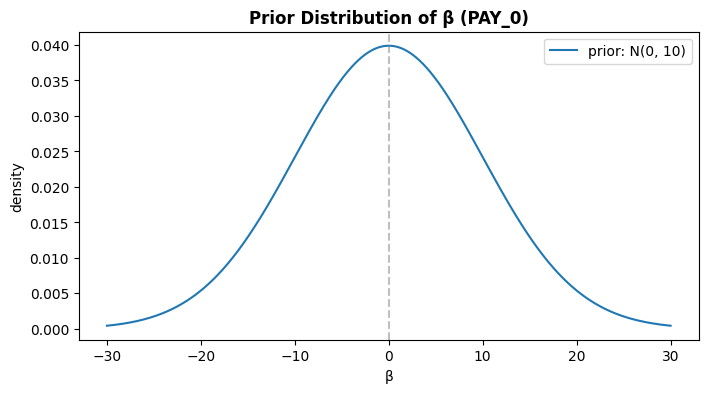

prior mean: 0
prior std: 10


In [27]:
# define prior
prior_mean = 0
prior_std = 10
beta_range = np.linspace(-30, 30, 1000)
prior_probs = norm.pdf(beta_range, prior_mean, prior_std)

plt.figure(figsize=(8, 4))
plt.plot(beta_range, prior_probs,label='prior: N(0, 10)')
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('Prior Distribution of β (PAY_0)', weight='bold')
plt.xlabel('β')
plt.ylabel('density')
plt.legend()
plt.show()

print(f"prior mean: {prior_mean}")
print(f"prior std: {prior_std}")

## Likelihood Function

With the prior defined, the next ingredient we need is the **likelihood**, which tells us how probable our observed data is given a particular value of $\beta$. 

For a single observation, the probability of default given their payment status is:

$$P(Y = 1 \mid x) = \sigma(\beta \cdot x) = \frac{1}{1 + e^{-\beta x}}$$

Extending this across all $n$ observations, the full likelihood is:

$$L(\beta) = \prod_{i=1}^{n} \sigma(\beta x_i)^{y_i} \cdot (1 - \sigma(\beta x_i))^{1 - y_i}$$

Since multiplying many small probabilities together cuases the result to become near zero, so we take the log and sum instead:

$$\ell(\beta) = \sum_{i=1}^{n} \left[ y_i \log \sigma(\beta x_i) + (1 - y_i) \log(1 - \sigma(\beta x_i)) \right]$$

In [28]:
def log_likelihood(beta, X, y):
    # compute predicted probability for each observation
    logits = beta * X
    probs = expit(logits)
    # sum log-probability across all observations
    return np.sum(y * np.log(probs) + (1 - y) * np.log(1 - probs))

def log_prior(beta, mean=0, std=10):
    # log of normal(0, 10) prior
    return norm.logpdf(beta, mean, std)

def log_posterior(beta, X, y):
    # posterior is proportional to likelihood times prior 
    return log_likelihood(beta, X, y) + log_prior(beta)

## Grid Search for the Posterior

Now that we have both the prior and the likelihood defined, we can compute the posterior.

For each candidate $\beta$ on the grid, we compute:

$$\log P(\beta \mid \text{data}) = \ell(\beta) + \log P(\beta)$$

Since we are working in log space, we exponentiate the results to get back to probability scale, then normalize so the distribution sums to 1:

$$P(\beta \mid \text{data}) = \frac{\exp\left(\log P(\beta \mid \text{data})\right)}{\sum_{\beta} \exp\left(\log P(\beta \mid \text{data})\right)}$$

We use a wide grid of 1000 points ranging from $-3$ to $3$, which covers all plausible values of $\beta$ without assuming anything about where the posterior will land.

In [33]:
# define grid of beta values to evaluate posterior on
beta_grid = np.linspace(-3, 3, 1000)

# evaluate log-posterior at each point on the grid
log_post_values = np.array([log_posterior(b, X, y) for b in beta_grid])

# shift log-posterior values so max is 0 to avoid numerical issues when exponentiating
log_post_shifted = log_post_values - log_post_values.max()
post_values = np.exp(log_post_shifted)

# normalize so the posterior integrates to 1
dx = beta_grid[1] - beta_grid[0]
post_values = post_values / (post_values.sum() * dx)

# posterior mean and std
posterior_mean = np.sum(beta_grid * post_values * dx)
posterior_std = np.sqrt(np.sum((beta_grid - posterior_mean)**2 * post_values * dx))

print(f"posterior mean: {posterior_mean:.4f}")
print(f"posterior std: {posterior_std:.4f}")

posterior mean: 0.5611
posterior std: 0.0122


## Posterior Distribution

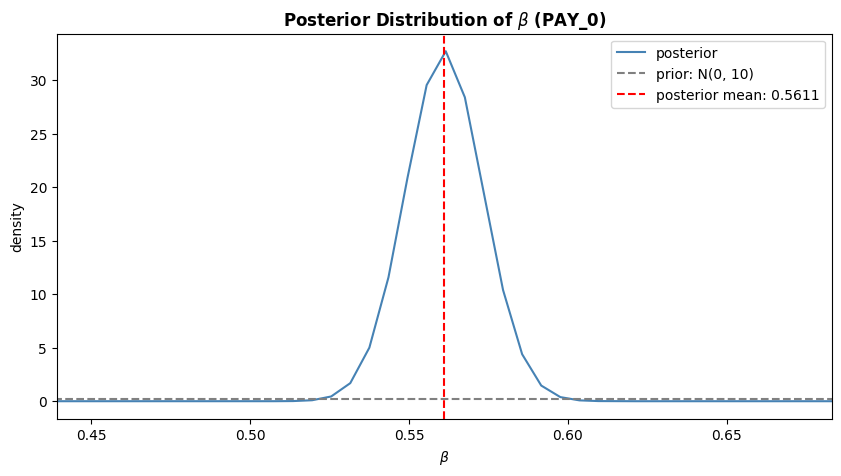

In [30]:
# zoom in around the posterior mean to see the actual bell curve shape
zoom_width = 10 * posterior_std
x_min = posterior_mean - zoom_width
x_max = posterior_mean + zoom_width

# rescale prior to same y-axis for visual comparison
prior_on_grid = norm.pdf(beta_grid, prior_mean, prior_std)
prior_on_grid = prior_on_grid / (prior_on_grid.sum() * dx)

plt.figure(figsize=(10, 5))
plt.plot(beta_grid, post_values, color='steelblue', label='posterior')
plt.plot(beta_grid, prior_on_grid, color='gray', linestyle='--', label='prior: N(0, 10)')
plt.axvline(posterior_mean, color='red', linestyle='--', label=f'posterior mean: {posterior_mean:.4f}')
plt.xlim(x_min, x_max)
plt.title('Posterior Distribution of $\\beta$ (PAY_0)', weight='bold')
plt.xlabel('$\\beta$')
plt.ylabel('density')
plt.legend()
plt.show()

## Credible Interval

A **credible interval** is the Bayesian equivalent of a confidence interval. It answers the question: given the data we observed, what range of $\beta$ values contains 95% of the posterior probability?

We compute it by building the cumulative distribution function (CDF) of the posterior and finding the values of $\beta$ where the CDF crosses 2.5% and 97.5%:

$$\text{95% Credible Interval} = \left[\beta_{0.025},\ \beta_{0.975}\right]$$

This has a direct and intuitive interpretation: there is a 95% probability that the true $\beta$ lies within this interval, given the data. This is subtly but importantly different from a frequentist confidence interval, which makes no probability statement about the parameter itself.

posterior mean:        0.5611
95% credible interval: [0.5375, 0.5856]


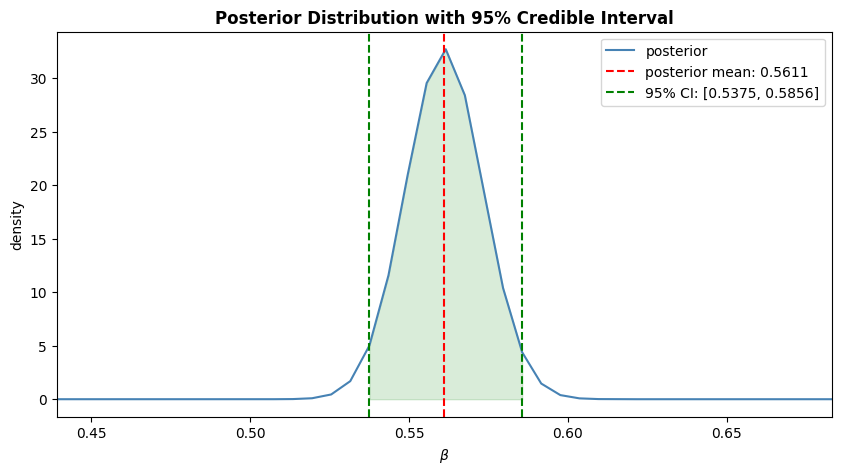

In [ ]:
# build the CDF from the posterior
cdf = np.cumsum(post_values * dx)

# find beta values at 2.5% and 97.5% of the CDF
ci_lower = beta_grid[np.searchsorted(cdf, 0.025)]
ci_upper = beta_grid[np.searchsorted(cdf, 0.975)]

print(f"posterior mean:        {posterior_mean:.4f}")
print(f"95% credible interval: [{ci_lower:.4f}, {ci_upper:.4f}]")

# zoom in around the posterior mean to see the actual bell curve shape and credible interval
zoom_width = 10 * posterior_std
x_min = posterior_mean - zoom_width
x_max = posterior_mean + zoom_width

plt.figure(figsize=(10, 5))
plt.plot(beta_grid, post_values, color='steelblue', label='posterior')
plt.axvline(posterior_mean, color='red', linestyle='--', label=f'posterior mean: {posterior_mean:.4f}')
plt.axvline(ci_lower, color='green', linestyle='--', label=f'95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]')
plt.axvline(ci_upper, color='green', linestyle='--')
plt.fill_between(beta_grid, post_values,
                 where=(beta_grid >= ci_lower) & (beta_grid <= ci_upper),
                 color='green', alpha=0.15)
plt.xlim(x_min, x_max)
plt.title('Posterior Distribution with 95% Credible Interval', weight='bold')
plt.xlabel('$\\beta$')
plt.ylabel('density')
plt.legend()
plt.show()

## Posterior Prediction Result

Now that we have estimated the posterior distribution of $\beta$, we can evaluate how well our model actually predicts credit default. We do this by using the **posterior mean** as our point estimate for $\beta$, then computing predicted default probabilities for each observation:

$$\hat{P}(\text{default}_i) = \sigma(\hat{\beta} \cdot \text{PAY\_0}_i) = \frac{1}{1 + e^{-\hat{\beta} \cdot \text{PAY\_0}_i}}$$

We then compare these predictions against the true labels using accuracy, recall, and AUC. AUC in particular measures how well the model separates defaulters from non-defaulters, where 0.5 is random guessing and 1.0 is perfect.

posterior mean: 0.5611
accuracy: 0.4147
recall: 0.8012
auc: 0.6897


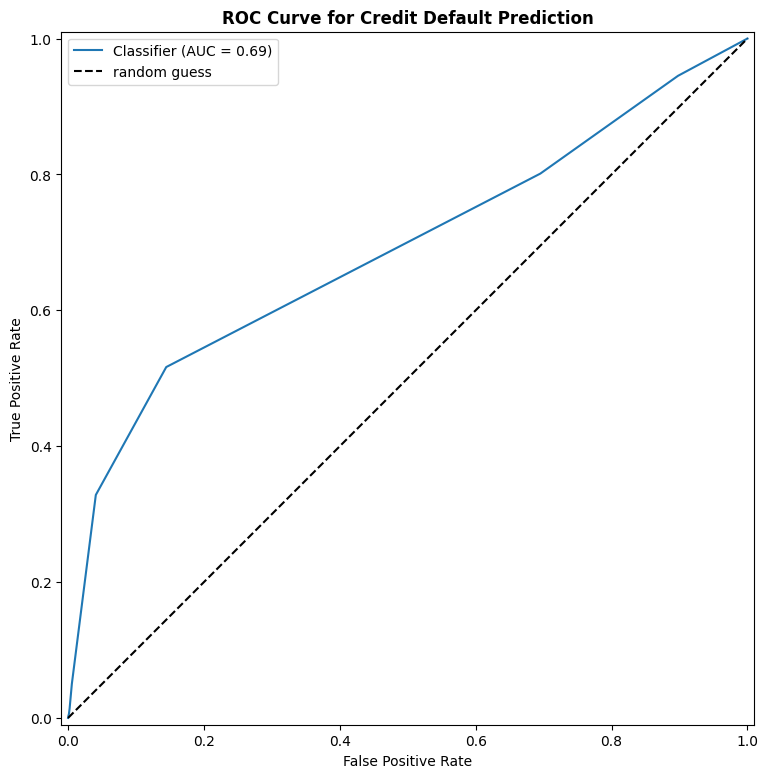

In [42]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, RocCurveDisplay

# use posterior mean as point estimate for beta
beta_hat = posterior_mean

# compute predicted probabilities for each observation
p_pred = expit(beta_hat * X)

# convert to binary predictions using 0.5 threshold
y_pred = (p_pred >= 0.5).astype(int)

# compute evaluation metrics
accuracy = accuracy_score(y, y_pred)
recall = recall_score(y, y_pred)
auc = roc_auc_score(y, p_pred)

print(f"posterior mean: {beta_hat:.4f}")
print(f"accuracy: {accuracy:.4f}")
print(f"recall: {recall:.4f}")
print(f"auc: {auc:.4f}")
fig, ax = plt.subplots(figsize=(9, 9))
RocCurveDisplay.from_predictions(y, p_pred, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='random guess')
ax.set_title('ROC Curve for Credit Default Prediction', weight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.show()